In [29]:
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

import umap

# Make sure path to wherever sherlock is located
sys.path.append("../..")

import sherlock as slk
from sherlock.tools._models import cVAE
from sherlock.tools._cvae_trainer import CVAETrainer
from sherlock.tools._datasets import PerturbMatchingDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [ ]:
data = slk.datasets.replogle()
data

AnnData object with n_obs × n_vars = 118641 × 1185
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'treatment', 'pert'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    uns: 'pathways'

In [31]:
dataset = PerturbMatchingDataset(data, seed=0)

batch_size = 64
num_workers = 0 

n = len(dataset)
n_val = int(0.1 * n)
n_train = n - n_val

train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(0)
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

print("batches:", len(train_loader), len(val_loader))
print("n_train/n_val:", n_train, n_val)


batches: 1641 183
n_train/n_val: 104977 11664


In [32]:
slk.pp.treat_effect(
    data,
    label_col="pert",
    control_label="NTC",
    method="perturbseq",
    inplace=True,
    key="treat_effect",
)

treat_effect = data.uns["treat_effect"]
print("treat_effect:", type(treat_effect), treat_effect.shape)


100%|██████████| 681/681 [00:04<00:00, 149.94it/s]

treat_effect: <class 'anndata._core.anndata.AnnData'> (681, 1185)


In [33]:
input_dim = data.n_vars
latent_dim = 64

perturbs = len(dataset.perturbation_dict)
conds = len(dataset.condition_dict)

print("input_dim:", input_dim, "latent_dim:", latent_dim)
print("perturbs:", perturbs, "conds:", conds)

model = cVAE(
    input_dim=input_dim,
    latent_dim=latent_dim,
    perturbs=perturbs,
    conds=conds,
    use_conditions=True,   # ok even if conds=1
    hidden_dim=128,
).to(device)

model

input_dim: 1185 latent_dim: 64
perturbs: 681 conds: 1


cVAE(
  (p_emb): Embedding(681, 64)
  (c_emb): Embedding(1, 64)
  (input_to_hidden_prior): Linear(in_features=1313, out_features=128, bias=True)
  (h_to_mu_prior): Linear(in_features=128, out_features=64, bias=True)
  (h_to_logvar_prior): Linear(in_features=128, out_features=64, bias=True)
  (input_to_hidden_posterior): Linear(in_features=2498, out_features=128, bias=True)
  (h_to_mu_posterior): Linear(in_features=128, out_features=64, bias=True)
  (h_to_logvar_posterior): Linear(in_features=128, out_features=64, bias=True)
  (z_to_h): Linear(in_features=192, out_features=128, bias=True)
  (h_to_nb): Linear(in_features=128, out_features=2370, bias=True)
)

In [34]:
trainer = CVAETrainer(
    cVAE=model,
    dataloader=train_loader,
    val_dataloader=val_loader,
    treat_effect=treat_effect,
    lr=1e-3,
    num_epochs=5,          # bump later; keep small for quick run
    validate_every=1,
    device=device,
    patience=10,
)

trained_model = trainer.fit()

print("Final tracked metrics:", trainer._last_valid)


Training cVAE on cpu …


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Average loss: 1.7485, Reconstruction loss: 1.7343 |KL Divergence: 0.1421 |
decoder sensitivity |pred(p+1)-pred(p)| mean abs: 0.08129486441612244
Validation loss: 1.7108
VALIDATE ran. pred_p shape: (11664, 1185) pred_ntc shape: (11664, 1185) all_P shape: (11664,)
effect stats: mean 0.00037646526518039813 std 0.014961714439152821 min -0.5890586376190186 max 2.2821288108825684
effect stats: mean 0.0006876333027477405 std 0.021838066047656375 min -0.8563032150268555 max 2.2821288108825684
effect stats: mean 0.001063937560455354 std 0.025357135351592987 min -0.8563032150268555 max 2.2925212383270264
effect stats: mean 0.0016003376852376807 std 0.030533451861118516 min -0.8563032150268555 max 2.2925212383270264
effect stats: mean 0.001971406302941076 std 0.03270149238124517 min -0.8563032150268555 max 2.2925212383270264
effect stats: mean 0.0022775955999503284 std 0.03478795789745303 min -0.8563032150268555 max 2.2925212383270264
effect stats: mean 0.002893286822156058 std 0.040300

Epochs:  20%|██        | 1/5 [00:17<01:11, 17.80s/it, ate=0.1332, score=1.7108, train=1.7485, val_loss=1.7108]

effect stats: mean 0.24473257134289214 std 0.3364305420969354 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.2453065200654917 std 0.33677620289253174 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.245597013459212 std 0.33678978983660285 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.24587109758808753 std 0.3368708264674241 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.24624976712982274 std 0.33684213811165375 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.24667634354743867 std 0.33681202281572736 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.24713713468283324 std 0.3368333450374159 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.2476633248571382 std 0.3370344976754423 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.24800852249208402 std 0.3370198979466424 min -2.8086671829223633 max 4.533531188964844
effect stats: mean 0.2483075

...

effect stats: mean 0.28772655018736415 std 0.3541595233858476 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.28821679239930337 std 0.354257294591133 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.28873247793797696 std 0.35463203647341124 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.2892457909944712 std 0.3545990035359779 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.28966903560473334 std 0.35458327826105995 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.2902160917486913 std 0.3546255755382106 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.29062852216376295 std 0.35461682941224826 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.29115308959918573 std 0.35453605613302486 min -2.6398327350616455 max 4.8878021240234375
effect stats: mean 0.29169213015924766 std 0.35486023648227893 min -2.6398327350616455 max 4.8878021240234375
effect stats: mea

Epochs:  80%|████████  | 4/5 [01:10<00:17, 17.71s/it, ate=0.3002, score=1.7009, train=1.7019, val_loss=1.7009]

effect stats: mean 0.2846104947508005 std 0.3599267075794032 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.28503253609814516 std 0.3600557053120364 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.28560693067413834 std 0.36031351735300937 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.2860525833073537 std 0.36038864897651696 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.2864014061507723 std 0.3608407618313769 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.28685703252286837 std 0.36098701597350014 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.28726600980104555 std 0.3613361917004861 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.2876930460582828 std 0.36129022595765176 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.2879855037730626 std 0.3613157405396078 min -3.3049466609954834 max 6.290126800537109
effect stats: mean 0.28846242

Epochs: 100%|██████████| 5/5 [01:28<00:00, 17.68s/it, ate=0.3368, score=1.7008, train=1.7005, val_loss=1.7008]

effect stats: mean 0.2879188211826736 std 0.3639151650632613 min -2.285438299179077 max 5.281600475311279
effect stats: mean 0.28862117919931357 std 0.3640724472631836 min -2.285438299179077 max 5.281600475311279
effect stats: mean 0.28928627763490883 std 0.36432823365320244 min -2.285438299179077 max 5.281600475311279
effect stats: mean 0.28988944449466075 std 0.3643582273568182 min -2.285438299179077 max 5.281600475311279
effect stats: mean 0.29044528852284074 std 0.36583375344614055 min -2.396237850189209 max 5.281600475311279
effect stats: mean 0.2909624973045094 std 0.3657564865040443 min -2.396237850189209 max 5.281600475311279
effect stats: mean 0.29139841534020755 std 0.3656945910875213 min -2.396237850189209 max 5.281600475311279
effect stats: mean 0.29192008026271943 std 0.3657454885049006 min -2.396237850189209 max 5.281600475311279
effect stats: mean 0.2925584728814473 std 0.36597929112369415 min -2.396237850189209 max 5.281600475311279
effect stats: mean 0.2929333989708191

In [35]:
ate = trainer._last_valid.get("ATE", np.nan)
val_loss = trainer._last_valid.get("val_loss", np.nan)

print("ATE (corr):", ate)
print("val_loss:", val_loss)


ATE (corr): 0.33684048853836995
val_loss: 1.7008293710771154


In [36]:
trained_model.eval()

Z = []
P_all = []

with torch.no_grad():
    for X_p, X_ntc, p, c in val_loader:
        X_p = X_p.to(device).float()
        X_ntc = X_ntc.to(device).float()
        p = p.to(device).long()
        c = c.to(device).long()

        # IMPORTANT: use trainer's lognorm to match training inputs
        X_p_n = trainer._lognorm(X_p)
        X_ntc_n = trainer._lognorm(X_ntc)

        mu_q, logvar_q = trained_model.posterior(X_ntc_n, X_p_n, p, c)

        Z.append(mu_q.cpu().numpy())
        P_all.append(p.cpu().numpy())

Z = np.concatenate(Z, axis=0)
P_all = np.concatenate(P_all, axis=0)

print("Z:", Z.shape, "P_all:", P_all.shape)


Z: (11664, 64) P_all: (11664,)


/Users/mahsa/azizi_lab/PerturbVAE/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


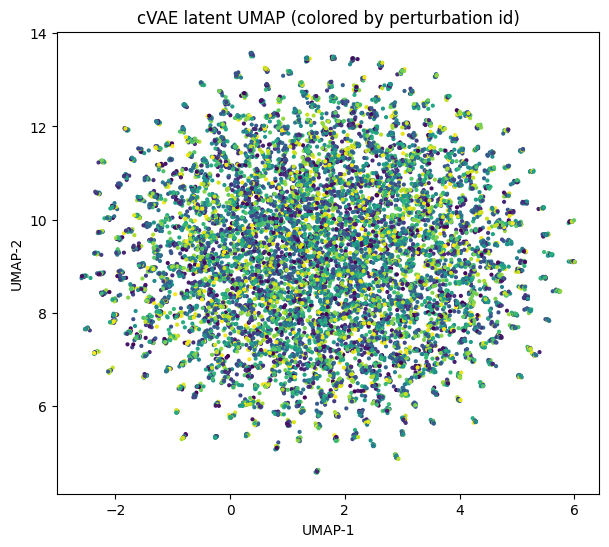

In [37]:
emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(Z)

plt.figure(figsize=(7, 6))
plt.scatter(emb[:, 0], emb[:, 1], s=4, c=P_all)
plt.title("cVAE latent UMAP (colored by perturbation id)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()
